✅ Dataset Loaded


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Features Added


,label,message,label_num,clean_message,char_count,word_count,digit_count,special_char_count,upper_case_word_count,avg_word_length,stopword_count,url_count,email_count,unique_word_count
0,ham,"Go until jurong point, crazy.. Available only ...",0,go until jurong point crazy available only in ...,111.0,20.0,0.0,9.0,0.0,4.600000,4.0,0.0,0.0,20.0
1,ham,Ok lar... Joking wif u oni...,0,ok lar joking wif u oni,29.0,6.0,0.0,6.0,0.0,4.000000,0.0,0.0,0.0,6.0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,free entry in a wkly comp to win fa cup final...,155.0,28.0,25.0,6.0,2.0,4.571429,5.0,0.0,0.0,24.0
3,ham,U dun say so early hor... U c already then say...,0,u dun say so early hor u c already then say,49.0,11.0,0.0,6.0,2.0,3.545455,2.0,0.0,0.0,10.0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,nah i dont think he goes to usf he lives aroun...,61.0,13.0,0.0,2.0,1.0,3.769231,5.0,0.0,0.0,12.0


✅ Model Performance


,precision,recall,f1-score,support
Ham,0.978659,0.996894,0.987692,966.000000
Spam,0.977099,0.859060,0.914286,149.000000
accuracy,0.978475,0.978475,0.978475,0.978475
macro avg,0.977879,0.927977,0.950989,1115.000000
weighted avg,0.978450,0.978475,0.977883,1115.000000


🔹 Accuracy: 0.9785


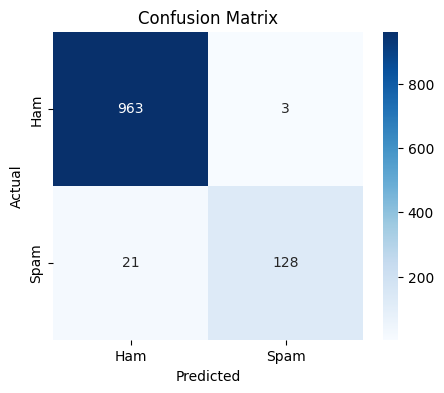

/tmp/ipython-input-2784213450.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", palette="Set2")


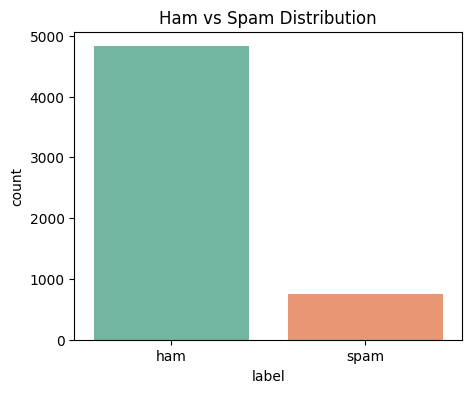

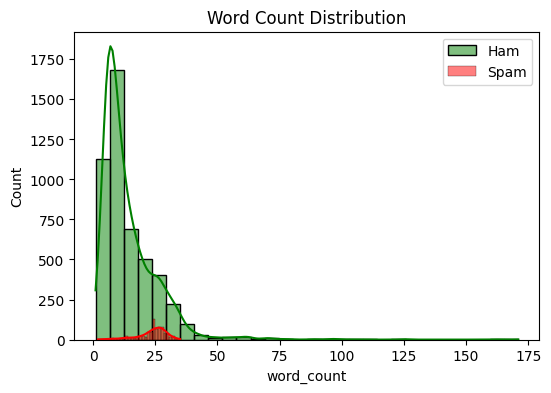

/tmp/ipython-input-2784213450.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y="avg_word_length", palette="Set2")


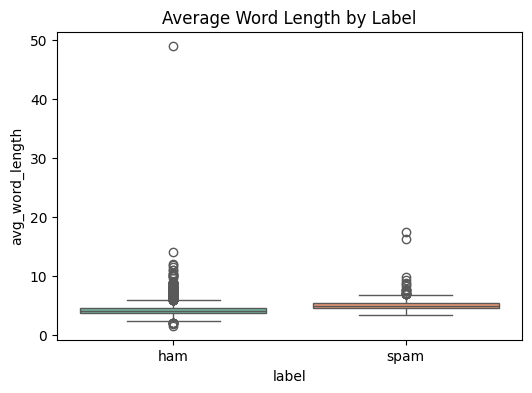

✅ Model Saved
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


from matplotlib import pyplot as plt
report_df['precision'].plot(kind='hist', bins=20, title='precision')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
report_df['recall'].plot(kind='hist', bins=20, title='recall')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
report_df['f1-score'].plot(kind='hist', bins=20, title='f1-score')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
report_df['support'].plot(kind='hist', bins=20, title='support')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
report_df.plot(kind='scatter', x='f1-score', y='support', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
report_df['precision'].plot(kind='line', figsize=(8, 4), title='precision')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
report_df['recall'].plot(kind='line', figsize=(8, 4), title='recall')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
report_df['f1-score'].plot(kind='line', figsize=(8, 4), title='f1-score')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
report_df['support'].plot(kind='line', figsize=(8, 4), title='support')
plt.gca().spines[['top', 'right']].set_visible(False)

In [4]:

# ============================================
# 📧 Email Spam Detection with ML
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, joblib, nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from scipy.sparse import hstack
from IPython.display import display

# --------------------------------------------
# 1. Load Dataset
# --------------------------------------------
df = pd.read_csv("spam.csv", encoding="latin-1")[["v1","v2"]]
df.columns = ["label","message"]

# Encode labels
df["label_num"] = df["label"].map({"ham":0, "spam":1})

print("✅ Dataset Loaded")
display(df.head())

# --------------------------------------------
# 2. Text Cleaning
# --------------------------------------------
nltk.download("stopwords")
stop_words = set(nltk.corpus.stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "URL", text)
    text = re.sub(r"\S+@\S+", "EMAIL", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["clean_message"] = df["message"].apply(clean_text)

# --------------------------------------------
# 3. Feature Engineering
# --------------------------------------------
def extract_features(text):
    words = text.split()
    return pd.Series({
        "char_count": len(text),
        "word_count": len(words),
        "digit_count": sum(c.isdigit() for c in text),
        "special_char_count": sum(c in string.punctuation for c in text),
        "upper_case_word_count": sum(1 for w in words if w.isupper()),
        "avg_word_length": np.mean([len(w) for w in words]) if words else 0,
        "stopword_count": sum(1 for w in words if w in stop_words),
        "url_count": len(re.findall(r"URL", text)),
        "email_count": len(re.findall(r"EMAIL", text)),
        "unique_word_count": len(set(words))
    })

features = df["message"].apply(extract_features)
df = pd.concat([df, features], axis=1)

print("✅ Features Added")
display(df.head())

# --------------------------------------------
# 4. Train-Test Split
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_message"], df["label_num"], test_size=0.2, random_state=42, stratify=df["label_num"]
)

# TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Extra Features
X_train_feat = features.loc[X_train.index]
X_test_feat = features.loc[X_test.index]

scaler = StandardScaler()
X_train_feat_scaled = scaler.fit_transform(X_train_feat)
X_test_feat_scaled = scaler.transform(X_test_feat)

# Combine TF-IDF + Features
X_train_final = hstack([X_train_tfidf, X_train_feat_scaled])
X_test_final = hstack([X_test_tfidf, X_test_feat_scaled])

# --------------------------------------------
# 5. Train Model
# --------------------------------------------
model = LogisticRegression(max_iter=200)
model.fit(X_train_final, y_train)
y_pred = model.predict(X_test_final)

# --------------------------------------------
# 6. Model Performance
# --------------------------------------------
report = metrics.classification_report(
    y_test, y_pred, target_names=["Ham","Spam"], output_dict=True
)
report_df = pd.DataFrame(report).transpose()

print("✅ Model Performance")
display(report_df)

accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"🔹 Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham","Spam"], yticklabels=["Ham","Spam"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --------------------------------------------
# 7. Data Visualizations
# --------------------------------------------

# Label Distribution
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="label", palette="Set2")
plt.title("Ham vs Spam Distribution")
plt.show()

# Word Count Distribution
plt.figure(figsize=(6,4))
sns.histplot(df[df["label"]=="ham"]["word_count"], color="green", label="Ham", bins=30, kde=True)
sns.histplot(df[df["label"]=="spam"]["word_count"], color="red", label="Spam", bins=30, kde=True)
plt.legend()
plt.title("Word Count Distribution")
plt.show()

# Average word length distribution
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="label", y="avg_word_length", palette="Set2")
plt.title("Average Word Length by Label")
plt.show()

# --------------------------------------------
# 8. Save Model
# --------------------------------------------
joblib.dump((model, tfidf, scaler), "spam_email_detector.joblib")
print("✅ Model Saved")